In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier,plot_tree

In [113]:
df = pd.read_csv('heart_disease.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,FALSE,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,FALSE,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,FALSE,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,FALSE,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,TRUE,1.5,flat,fixed defect,0


In [114]:
df.shape

(908, 13)

In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [116]:
df.duplicated().sum()

np.int64(0)

### EDA 

In [117]:
### Handle missing value

df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [118]:
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].mean())

In [119]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

In [120]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,FALSE,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,FALSE,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,FALSE,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,FALSE,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,TRUE,1.5,flat,fixed defect,0


In [121]:
#### outlier capping
def outiler_capping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR=Q3-Q1
    Lower_Extreme= Q1-1.5*IQR
    Upper_Extreme= Q3+1.5*IQR
    df[column]= df[column].apply(lambda x:Lower_Extreme if x<Lower_Extreme else Upper_Extreme if x>Upper_Extreme else x)
for col in df.select_dtypes(['int','float']).columns:
    outiler_capping(df,col)

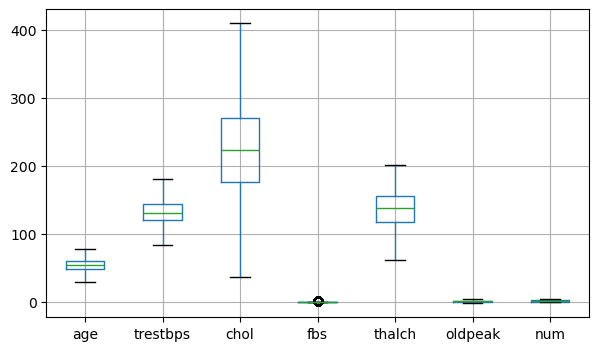

In [122]:
### Outlier Capping
df.boxplot()
plt.show()

In [123]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", numeric_cols)

Numeric columns: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'num']


In [124]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist
cat_cols

<bound method IndexOpsMixin.tolist of Index(['sex', 'cp', 'restecg', 'exang', 'slope', 'thal'], dtype='object')>

In [127]:
from sklearn.preprocessing import LabelEncoder,StandardScaler

le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

In [128]:
### Scaling 
std_sca = StandardScaler()
df1 = pd.DataFrame(std_sca.fit_transform(df),columns=df.columns)
df1.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,1.006027,0.514416,2.320276,0.676728,0.111418,1.976894,-1.561352,0.529131,-0.787899,1.438815,-1.672770,-1.456276,-0.881977
1,-1.397560,0.514416,0.232258,0.179534,-0.392154,-0.505844,0.013879,-0.154785,-0.787899,-0.897946,-0.224843,-1.456276,-0.881977
2,0.350503,0.514416,-0.811752,0.428131,-0.576798,-0.505844,0.013879,0.453140,-0.787899,-0.508486,-0.224843,-1.456276,-0.881977
3,-0.195767,0.514416,2.320276,-0.814852,-0.643941,-0.505844,-1.561352,1.972953,-0.787899,-0.897946,-0.224843,-1.456276,-0.881977
4,0.350503,0.514416,-0.811752,-1.249896,-0.425726,-0.505844,0.013879,-0.382757,0.961275,0.659895,-0.224843,-1.456276,-0.881977


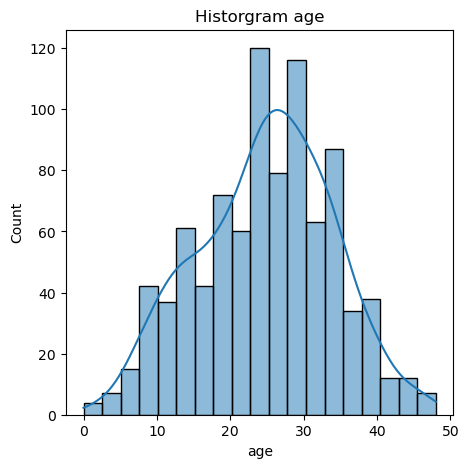

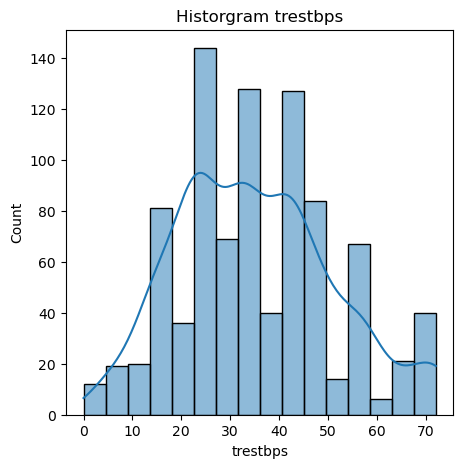

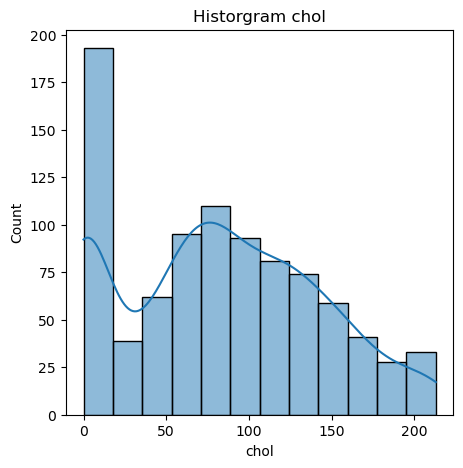

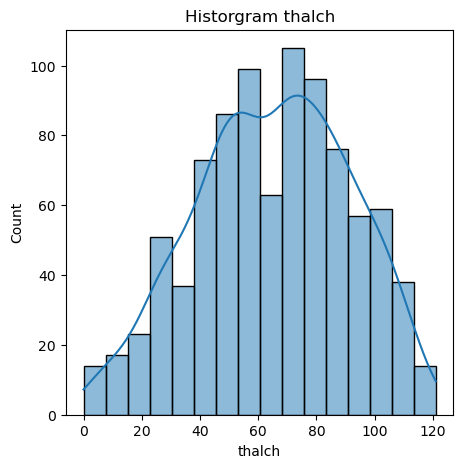

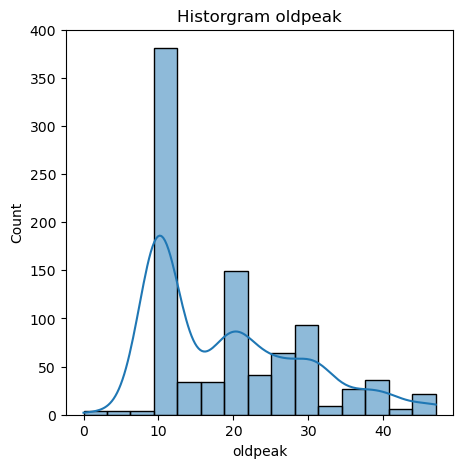

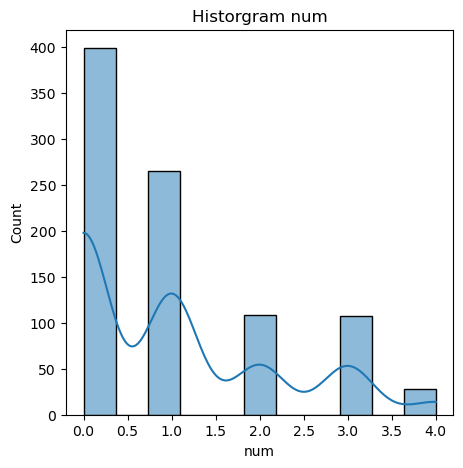

In [129]:
for i in ['age','trestbps', 'chol', 'thalch', 'oldpeak', 'num']:
    plt.figure(figsize = (5,5))
    sns.histplot(x = df[i],kde= True)
    plt.xlabel(i)
    plt.ylabel('Count')
    plt.title(f'Historgram {i}')
    plt.show()

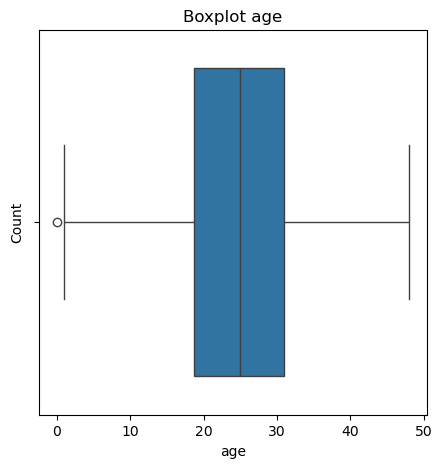

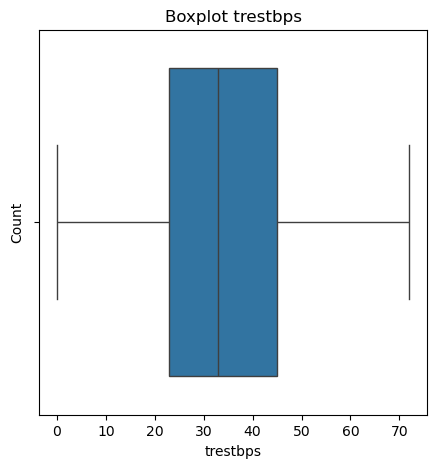

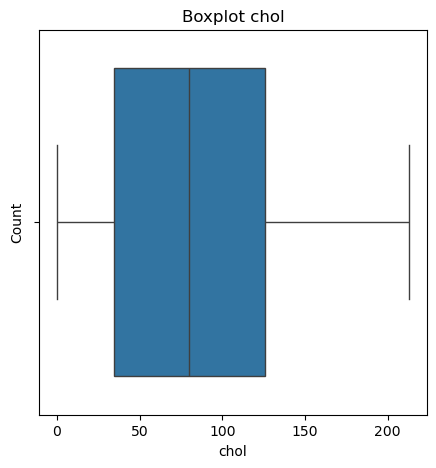

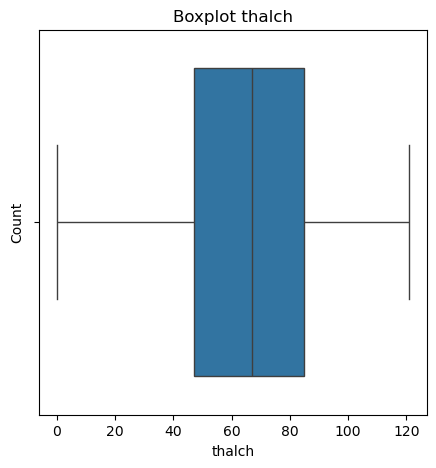

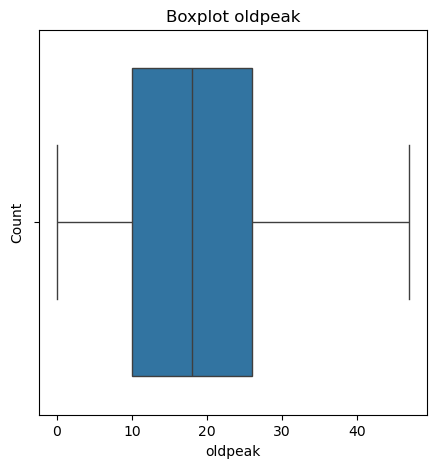

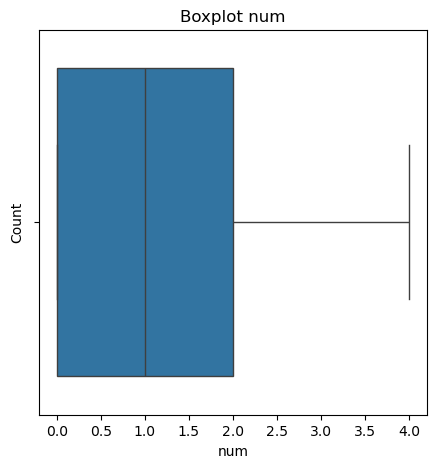

In [130]:
for i in ['age','trestbps', 'chol', 'thalch', 'oldpeak', 'num']:
    plt.figure(figsize=(5,5))
    sns.boxplot(x=df[i])
    plt.xlabel(i)
    plt.ylabel('Count')
    plt.title(f'Boxplot {i}')
    plt.show()

In [131]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,34,1,3,46,89,True,0,79,0,34,0,0,0
1,12,1,1,38,59,False,1,61,0,10,1,0,0
2,28,1,0,42,48,False,1,77,0,14,1,0,0
3,23,1,3,22,44,False,0,117,0,10,1,0,0
4,28,1,0,15,57,False,1,55,1,26,1,0,0


In [132]:
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

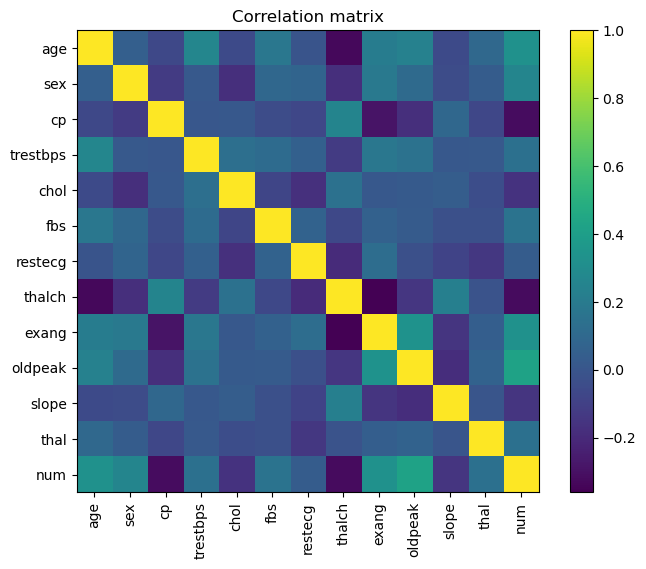

In [133]:
corr = df.corr()
plt.figure(figsize=(8,6))
plt.imshow(corr, interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation matrix")
plt.show()

### Feature Engineering

In [134]:
if 'num' not in df.columns:
    raise ValueError('Invalid Input')

In [135]:
df['target'] = (df['num'] > 0).astype(int)

In [136]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num,target
0,34,1,3,46,89,True,0,79,0,34,0,0,0,0
1,12,1,1,38,59,False,1,61,0,10,1,0,0,0
2,28,1,0,42,48,False,1,77,0,14,1,0,0,0
3,23,1,3,22,44,False,0,117,0,10,1,0,0,0
4,28,1,0,15,57,False,1,55,1,26,1,0,0,0


In [137]:
features = df.drop(columns=['num','target'])
targets = df['target']

In [138]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num,target
0,34,1,3,46,89,True,0,79,0,34,0,0,0,0
1,12,1,1,38,59,False,1,61,0,10,1,0,0,0
2,28,1,0,42,48,False,1,77,0,14,1,0,0,0
3,23,1,3,22,44,False,0,117,0,10,1,0,0,0
4,28,1,0,15,57,False,1,55,1,26,1,0,0,0


### Decision Tree Classifier 

In [139]:
### train_test_split

In [140]:
x_train,x_test,y_train,y_test = train_test_split(features,targets,train_size = 0.75,random_state=100)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(681, 12)
(227, 12)
(681,)
(227,)


In [141]:
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,f1_score,roc_auc_score

In [142]:
dec_tree = DecisionTreeClassifier(criterion='gini',splitter = 'best' ,max_depth = 5)
dec_tree.fit(x_train,y_train)
y_pred = dec_tree.predict(x_test)
accuracy_score(y_test,y_pred)

0.7268722466960352

In [143]:
dec_tree = DecisionTreeClassifier(criterion='gini',splitter = 'best',max_depth = 5)
dec_tree.fit(x_train,y_train)
y_pred = dec_tree.predict(x_test)
f1_score(y_test,y_pred,average='micro')

0.7312775330396476

In [144]:
dec_tree = DecisionTreeClassifier(criterion='gini',splitter = 'best' ,max_depth = 5)
dec_tree.fit(x_train,y_train)
y_pred = dec_tree.predict(x_test)
precision_score(y_test,y_pred,average = 'micro')

0.7312775330396476

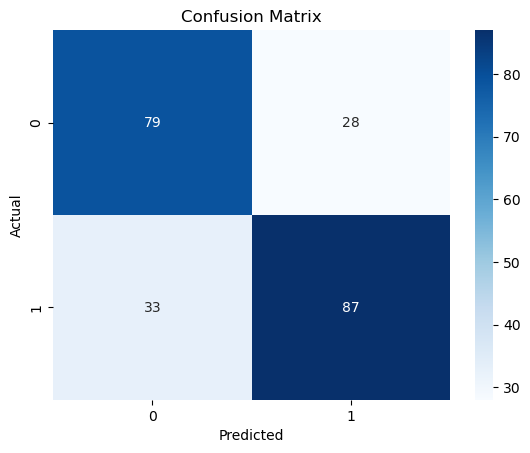

In [145]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [146]:
### Grid search 

params = {'criterion':['gini','entropy'],'splitter':['best','random'],'max_depth':range(1,5)}
grid_search = GridSearchCV(dec_tree, params)
grid_search.fit(x_train,y_train)
grid_search.best_params_

{'criterion': 'gini', 'max_depth': 3, 'splitter': 'best'}

In [147]:
dec_tree = DecisionTreeClassifier(criterion='gini',splitter = 'best' ,max_depth = 5)
dec_tree.fit(x_train,y_train)
y_pred = dec_tree.predict(x_test)
accuracy_score(y_test,y_pred)

0.7312775330396476

### Hyper Parameter Tuning

In [148]:
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    "criterion": ["gini","entropy"],
    "max_depth": [3,5,7,9, None],
    "min_samples_split": [2,5,10,20],
    "min_samples_leaf": [1,2,4]
}
rs = RandomizedSearchCV(DecisionTreeClassifier(random_state=42),
                        param_distributions=param_dist,
                        n_iter=20, cv=5, scoring='roc_auc', n_jobs=-1, random_state=42, refit=True)
rs.fit(x_train, y_train)
print("Best (randomized):", rs.best_params_, "CV roc_auc:", rs.best_score_)

Best (randomized): {'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 3, 'criterion': 'gini'} CV roc_auc: 0.828713600835167


In [149]:
### Randomized search

params = {'criterion':['gini','entropy'],'splitter':['best','random'],'max_depth':range(1,5)}
roc_search = GridSearchCV(dec_tree, params)
roc_search.fit(x_train,y_train)
roc_search.best_params_

{'criterion': 'gini', 'max_depth': 3, 'splitter': 'best'}

In [150]:
dec_tree = DecisionTreeClassifier(criterion='gini',splitter = 'best' ,max_depth = 3)
dec_tree.fit(x_train,y_train)
y_pred = dec_tree.predict(x_test)
roc_auc_score(y_test,y_pred)

0.7378504672897195

In [161]:
best_model = roc_search.best_estimator_
best_model

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [168]:
# --- Feature importances ---
importances = pd.Series(best_model.feature_importances_, index=features.columns).sort_values(ascending=False)
top5 = importances.head(5)
print("\nTop 5 Important Features:\n", top5)


Top 5 Important Features:
 cp          0.584314
chol        0.230306
oldpeak     0.083048
age         0.081177
trestbps    0.021155
dtype: float64


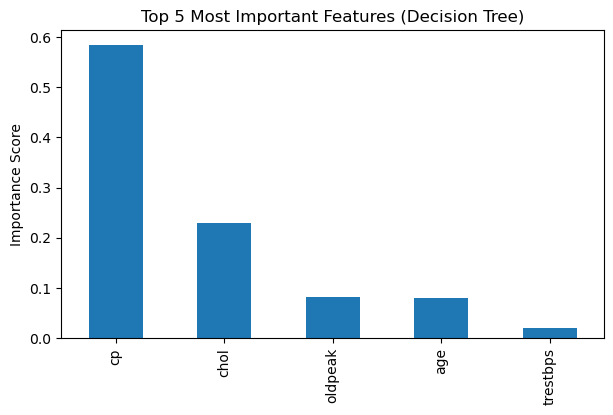

In [170]:
plt.figure(figsize=(7,4))
top5.plot(kind='bar')
plt.title("Top 5 Most Important Features (Decision Tree)")
plt.ylabel("Importance Score")
plt.show()

In [177]:
print("\nInterpretation of Important Features:")
for feature, score in top5.items():
    if "cp" in feature:
        print(f"- {feature}: Chest pain type strongly predicts heart disease.")
    elif "thal" in feature:
        print(f"- {feature}: Thalassemia test result is highly predictive of heart disease.")
    elif "oldpeak" in feature:
        print(f"- {feature}: ST depression (oldpeak) indicates exercise-induced ischemia.")
    elif "slope" in feature:
        print(f"- {feature}: Slope of ST segment (exercise ECG) differentiates risk levels.")
    elif "age" in feature:
        print(f"- {feature}: Older age generally increases risk of heart disease.")
    else:
        print(f"- {feature}: This feature contributes meaningfully to the prediction.")


Interpretation of Important Features:
- cp: Chest pain type strongly predicts heart disease.
- chol: This feature contributes meaningfully to the prediction.
- oldpeak: ST depression (oldpeak) indicates exercise-induced ischemia.
- age: Older age generally increases risk of heart disease.
- trestbps: This feature contributes meaningfully to the prediction.


### Decision Tree

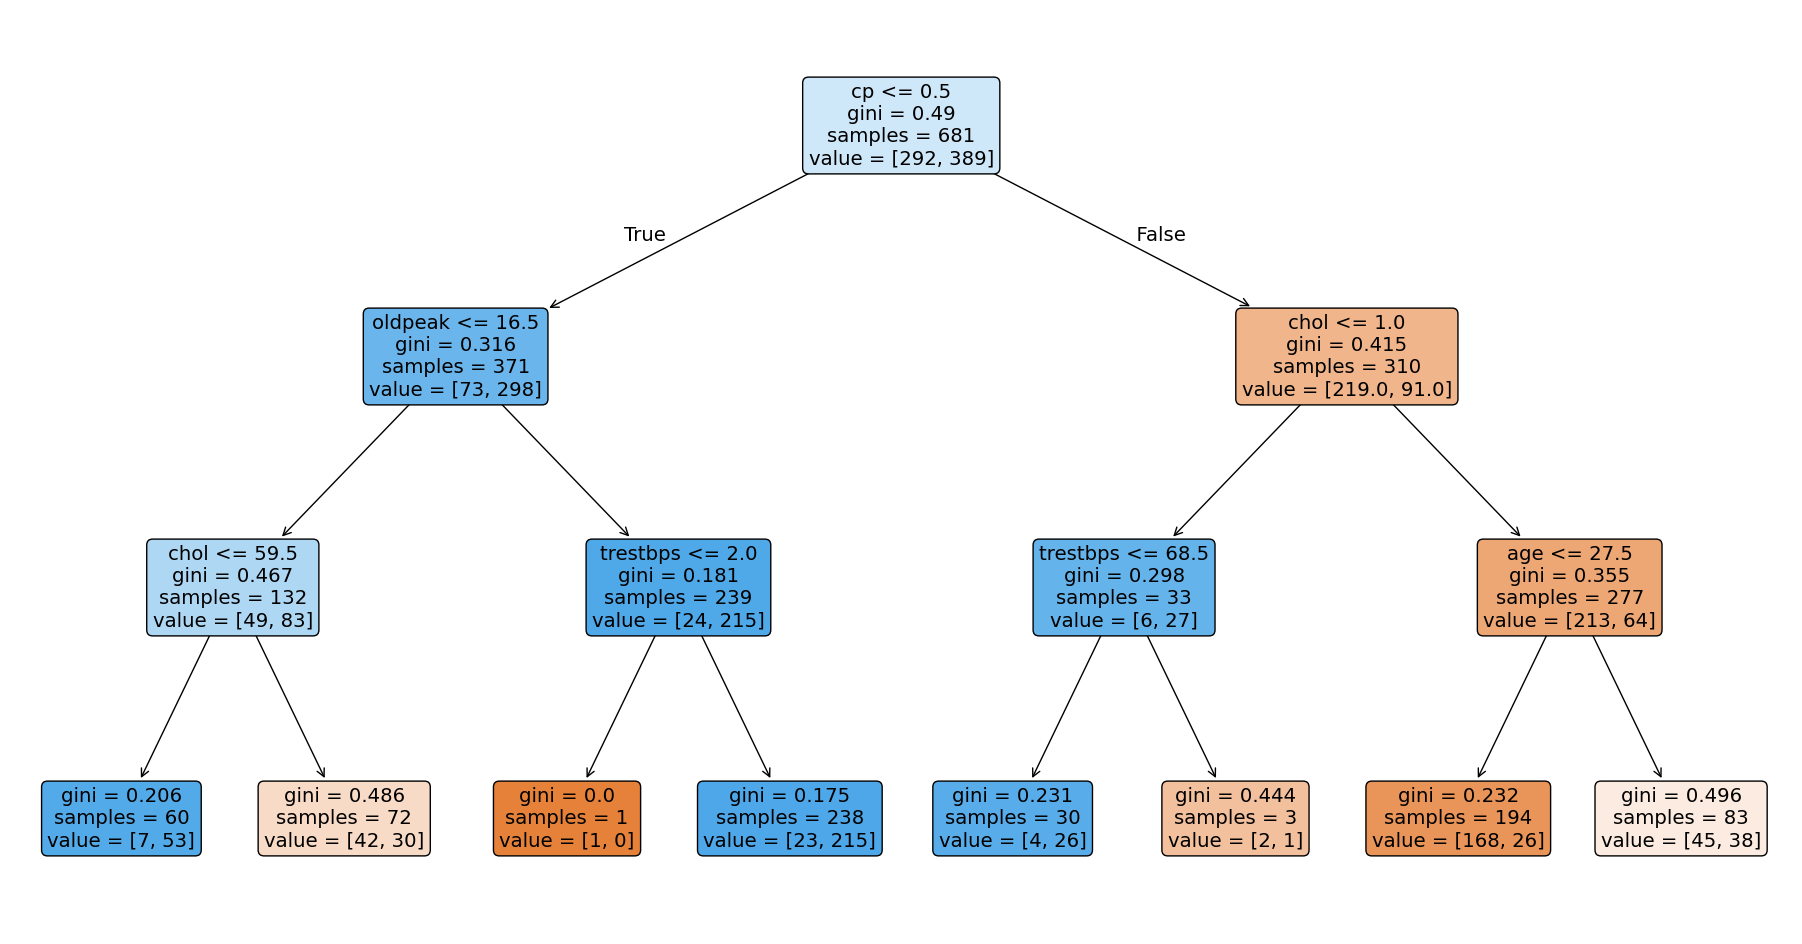

In [179]:
## plotting the dec _tree 

plt.figure(figsize= (23,12))
plot_tree ( dec_tree , filled = True, feature_names=list(features),rounded=True);
plt.show()

### Interview Questions

Interview Questions:
#### What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

criterion : {"gini", "entropy", "log_loss"}, default="gini"
    The function to measure the quality of a split. Supported criteria are
    "gini" for the Gini impurity and "log_loss" and "entropy" ,both for the
    Shannon information gain, see :ref:`tree_mathematical_formulation.

splitter : {"best", "random"}, default="best"
    The strategy used to choose the split at each node. Supported
    strategies are "best" ,to choose the best split and "random", to choose
    the best random split.

max_depth : int, default=None
    The maximum depth of the tree. If None, then nodes are expanded until
    all leaves are pure or until all leaves contain less than
    min_samples_split samples.

min_samples_split : int or float, default=2
    The minimum number of samples required to split an internal node:

#### What is the difference between the Label encoding and One-hot encoding?

Label encoding assigns each category an integer (e.g., A→0, B→1, C→2). 
Good for ordinal categories where integer order matters. For nominal categories, label encoding can introduce artificial ordering that many algorithms interpret as ordinal.

One-hot encoding creates binary indicator columns for each category (except optionally one dropped column). 
This avoids introducing ordinal relationships and is usually preferable for nominal categorical variables (especially for tree-based models it's OK to use either but one-hot can sometimes help with high-cardinality features).